In [1]:
from utils_dino_final_pylib import *
import time

start_time = time.time()

SOURCE_IMAGE_PATH = r"D:\3d-recon\datasets\ASARoomImage\d03.jpg"

c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Using device: cuda
final text_encoder_type: bert-base-uncased


c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\groundingdino\util\inference.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_checkp

In [2]:
wall_bboxes, wall_selected_points = get_wall_bboxes_points(SOURCE_IMAGE_PATH)

print("wall_bboxes", wall_bboxes)
print("wall_selected_points", wall_selected_points)

# print(type(wall_bboxes))
# print(wall_bboxes.shape)

# print(type(wall_selected_points))
# print(len(wall_selected_points))

Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\d03.jpg


c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\transformers\modeling_utils.py:1614: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\transformers\models\bert\modeling_bert.py:407: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\hci\.conda\envs\dino_docker\lib\site-packages\torch\_dynamo\eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two vari

wall_bboxes [[1.6056213e+00 7.1417236e-01 6.3542566e+02 1.1502600e+03]
 [1.3589651e+03 1.7299835e+01 1.9180642e+03 8.0820862e+02]
 [6.2812048e+02 3.0721329e+02 1.3638899e+03 7.3189050e+02]]
wall_selected_points [[183, 499], [1694, 399], [974, 707]]


In [3]:
(floor_bboxes, 
 floor_selected_points, 
 rug_bboxes,
 rug_to_floor_indices) = get_floor_bboxes_points_with_rug(SOURCE_IMAGE_PATH)

print("floor_bboxes", floor_bboxes)
print("floor_selected_points", floor_selected_points)

print("rug_bboxes", rug_bboxes)
print("rug_to_floor_indices", rug_to_floor_indices)

# print(type(floor_bboxes))
# print(floor_bboxes.shape)

# print(type(floor_selected_points))
# print(len(floor_selected_points))

# print(type(rug_bboxes))
# print(rug_bboxes.shape)

RUG:  0
There is overlap
Subtract rug from floor area NOT OK. Revert to original Floor!
floor_bboxes [[   2.0579834  732.70276   1915.419     1278.6747   ]]
floor_selected_points [[764, 978]]
rug_bboxes []
rug_to_floor_indices []


# Output for Client

In [4]:
output = {'wall_bboxes': wall_bboxes,
          'wall_selected_points':wall_selected_points,
          'floor_bboxes':floor_bboxes,
          'floor_selected_points': floor_selected_points,
          'rug_bboxes': rug_bboxes,
          'rug_to_floor_indices':rug_to_floor_indices}
print(time.time()-start_time)
output

3.467076539993286


{'wall_bboxes': array([[1.6056213e+00, 7.1417236e-01, 6.3542566e+02, 1.1502600e+03],
        [1.3589651e+03, 1.7299835e+01, 1.9180642e+03, 8.0820862e+02],
        [6.2812048e+02, 3.0721329e+02, 1.3638899e+03, 7.3189050e+02]],
       dtype=float32),
 'wall_selected_points': [[183, 499], [1694, 399], [974, 707]],
 'floor_bboxes': array([[   2.0579834,  732.70276  , 1915.419    , 1278.6747   ]],
       dtype=float32),
 'floor_selected_points': [[764, 978]],
 'rug_bboxes': array([], dtype=float64),
 'rug_to_floor_indices': []}

In [5]:
import time

start_time = time.time()

image = cv2.imread(SOURCE_IMAGE_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

checkpoint = r"./sam_vit_h_4b8939.pth"

model_type = "vit_h"
sam = sam_model_registry[model_type](checkpoint=checkpoint)

print(time.time()-start_time)

sam.to(device='cuda')
predictor = SamPredictor(sam)
predictor.set_image(image)
image_embedding = predictor.get_image_embedding().cpu().numpy()

np.save("image_embedding_vith.npy", image_embedding)

print(time.time()-start_time)

(1280, 1920, 3)
3.1054155826568604
7.346704721450806


In [6]:
print(image.shape)

(1280, 1920, 3)


In [7]:
def get_onnx_mask_from_bboxes(bboxes, ort_session):

    onnx_coord = np.concatenate([xyxy.reshape(1,2,2) for xyxy in bboxes], axis=0)#[None, :, :]
    onnx_label = np.concatenate([np.array([2,3]).reshape(1,2) for _ in range(bboxes.shape[0])], axis=0).astype(np.float32) #[None, :].astype(np.float32)

    print(onnx_coord.shape)
    print(onnx_label.shape)

    print(image.shape[:2])

    onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)

    onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
    onnx_has_mask_input = np.zeros(1, dtype=np.float32)

    ort_inputs = {
        "image_embeddings": image_embedding,
        "point_coords": onnx_coord,
        "point_labels": onnx_label,
        "mask_input": onnx_mask_input,
        "has_mask_input": onnx_has_mask_input,
        "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
    }

    masks, _, _ = ort_session.run(None, ort_inputs)
    masks = masks > predictor.model.mask_threshold
    print(masks.shape)

    return masks

In [8]:
import onnxruntime

onnx_model_path = "sam_onnx_vith_batch.onnx"
ort_session = onnxruntime.InferenceSession(onnx_model_path)
wall_masks = get_onnx_mask_from_bboxes(wall_bboxes, ort_session)

ort_session = onnxruntime.InferenceSession(onnx_model_path)
floor_masks = get_onnx_mask_from_bboxes(floor_bboxes, ort_session)

if len(rug_bboxes)>0:
    ort_session = onnxruntime.InferenceSession(onnx_model_path)
    rug_masks = get_onnx_mask_from_bboxes(rug_bboxes, ort_session)

(3, 2, 2)
(3, 2)
(1280, 1920)
(3, 1, 1280, 1920)
(1, 2, 2)
(1, 2)
(1280, 1920)
(1, 1, 1280, 1920)


In [9]:
# Step 1: Convert to uint8 (0 and 255)
mask_uint8 = (wall_masks[0].squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)

# Step 2: Save as JPG
cv2.imwrite("wall_mask.jpg", mask_uint8)

True

(1, 1280, 1920)
(1, 1280, 1920)
(1, 1280, 1920)


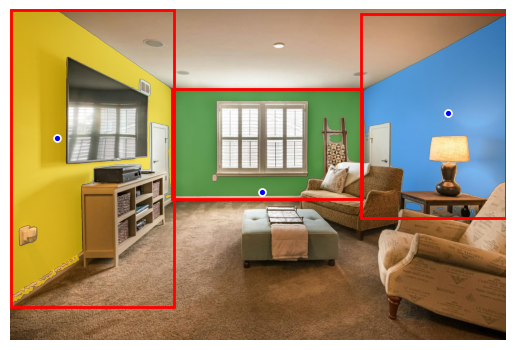

True

In [14]:
plt.imshow(image)

for mask, bbox, point in zip(wall_masks, wall_bboxes, wall_selected_points):
    print(mask.shape)
    show_mask(mask, plt.gca())
    show_box(bbox, plt.gca())
    show_point(point, plt.gca())
plt.axis('off')
plt.show()

# Step 1: Convert to uint8 (0 and 255)
mask_uint8 = (mask.squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)

# Step 2: Save as JPG
cv2.imwrite("mask.jpg", mask_uint8)

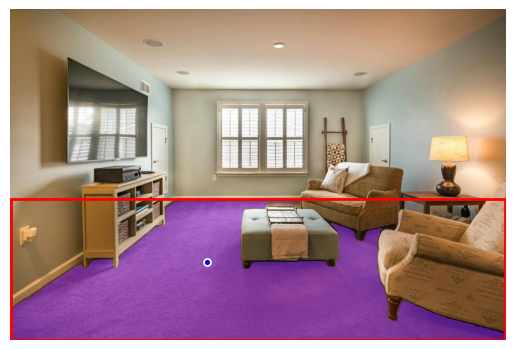

In [15]:
plt.imshow(image)

for mask, bbox, point in zip(floor_masks, floor_bboxes, floor_selected_points):
    show_mask(mask, plt.gca())
    show_box(bbox, plt.gca())
    show_point(point, plt.gca())
plt.axis('off')
plt.show()

In [16]:
if len(rug_bboxes)>0:
    plt.imshow(image)

    for mask, bbox in zip(rug_masks, rug_bboxes):
        show_mask(mask, plt.gca())
        show_box(bbox, plt.gca())
    plt.axis('off')
    plt.show()